In [6]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_squared_error, mean_squared_log_error

In [7]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder

In [12]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

builder = ModelDatasetBuilder(db_path)

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2025-10-01",
    add_time_features=False,
    lags=None,
    target_horizon=None,
    include_volumes=False,
    dropna=False
)

df.head()
df.tail()


,price_id,zone_id,delivery_day,hour,price_value
datetime,,,,,
2025-09-30 17:00:00,1007892,12,2025-09-30,19,69.96
2025-09-30 18:00:00,1007912,12,2025-09-30,20,59.94
2025-09-30 19:00:00,1007932,12,2025-09-30,21,52.99
2025-09-30 20:00:00,1007952,12,2025-09-30,22,47.38
2025-09-30 21:00:00,1007972,12,2025-09-30,23,43.98


In [14]:
# ============================================================
# 4. CREATE TEMPORAL SERIES
# ============================================================

df_model = df[
    [
        "price_value"
    ]
].asfreq("h").dropna()

ts = df_model["price_value"]

print("Length:", ts.shape)
print("Duplicates:", ts.index.duplicated().sum())
print("Missing price:", ts.isna().sum())
print("Start:", ts.index.min())
print("End:", ts.index.max())

display(df_model.head())
display(df_model.tail())

Length: (50398,)
Duplicates: 0
Missing price: 0
Start: 2020-01-01 00:00:00
End: 2025-09-30 21:00:00


,price_value
datetime,
2020-01-01 00:00:00,31.77
2020-01-01 01:00:00,31.57
2020-01-01 02:00:00,31.28
2020-01-01 03:00:00,30.72
2020-01-01 04:00:00,30.27


,price_value
datetime,
2025-09-30 17:00:00,69.96
2025-09-30 18:00:00,59.94
2025-09-30 19:00:00,52.99
2025-09-30 20:00:00,47.38
2025-09-30 21:00:00,43.98


In [19]:
# ============================================================
# 5. CREATE PRICE FEATURES AND PRICE EVENTS
# ============================================================

df_features = df_model.copy()

# ----------------------------
# Temporal features
# ----------------------------
df_features["year"] = df_features.index.year
df_features["month"] = df_features.index.month
df_features["day"] = df_features.index.day
df_features["day_of_week"] = df_features.index.dayofweek

# ----------------------------
# Lag features
# ----------------------------
df_features["price_value_lag_1"] = df_features["price_value"].shift(1)
df_features["price_value_lag_2"] = df_features["price_value"].shift(2)
df_features["price_value_lag_24"] = df_features["price_value"].shift(24)

# ----------------------------
# Price event thresholds
# ----------------------------
train_threshold_period = df_features.loc["2020-01-01":"2024-12-31 23:00:00"].copy()

p10 = train_threshold_period["price_value"].quantile(0.10)
p90 = train_threshold_period["price_value"].quantile(0.90)
p95 = train_threshold_period["price_value"].quantile(0.95)

df_features["price_delta"] = df_features["price_value"].diff()
df_features["abs_price_delta"] = df_features["price_delta"].abs()
df_features["rolling_volatility_24h"] = df_features["price_value"].rolling(window=24).std()

delta_p05 = train_threshold_period["price_value"].diff().quantile(0.05)
delta_p95 = train_threshold_period["price_value"].diff().quantile(0.95)
abs_delta_p95 = train_threshold_period["price_value"].diff().abs().quantile(0.95)
volatility_p90 = train_threshold_period["price_value"].rolling(window=24).std().quantile(0.90)

# ----------------------------
# Price events
# ----------------------------
df_features["low_price"] = (df_features["price_value"] < p10).astype(int)
df_features["high_price"] = (df_features["price_value"] > p90).astype(int)
df_features["price_spike"] = (df_features["price_value"] > p95).astype(int)
df_features["extreme_price"] = (df_features["price_value"] > p95).astype(int)

df_features["rapid_price_change"] = (
    df_features["abs_price_delta"] > abs_delta_p95
).astype(int)

df_features["price_ramp_up"] = (
    df_features["price_delta"] > delta_p95
).astype(int)

df_features["price_ramp_down"] = (
    df_features["price_delta"] < delta_p05
).astype(int)

df_features["high_volatility"] = (
    df_features["rolling_volatility_24h"] > volatility_p90
).astype(int)

display(df_features.head(30))

,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,price_delta,abs_price_delta,rolling_volatility_24h,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,31.77,2020,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0
2020-01-01 01:00:00,31.57,2020,1,1,2,31.77,NaN,NaN,-0.20,0.20,NaN,0,0,0,0,0,0,0,0
2020-01-01 02:00:00,31.28,2020,1,1,2,31.57,31.77,NaN,-0.29,0.29,NaN,0,0,0,0,0,0,0,0
2020-01-01 03:00:00,30.72,2020,1,1,2,31.28,31.57,NaN,-0.56,0.56,NaN,0,0,0,0,0,0,0,0
2020-01-01 04:00:00,30.27,2020,1,1,2,30.72,31.28,NaN,-0.45,0.45,NaN,0,0,0,0,0,0,0,0
2020-01-01 05:00:00,30.17,2020,1,1,2,30.27,30.72,NaN,-0.10,0.10,NaN,0,0,0,0,0,0,0,0
2020-01-01 06:00:00,30.14,2020,1,1,2,30.17,30.27,NaN,-0.03,0.03,NaN,0,0,0,0,0,0,0,0
2020-01-01 07:00:00,30.49,2020,1,1,2,30.14,30.17,NaN,0.35,0.35,NaN,0,0,0,0,0,0,0,0
2020-01-01 08:00:00,30.59,2020,1,1,2,30.49,30.14,NaN,0.10,0.10,NaN,0,0,0,0,0,0,0,0


In [36]:
# ============================================================
# 6. DEFINE FEATURE SETS
# ============================================================

price_base_features = [
    "price_value",
    "year",
    "month",
    "day",
    "day_of_week",
]

lag_features = [
    "price_value_lag_1",
    "price_value_lag_2",
    "price_value_lag_24",
]

price_event_features = [
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",
]

# Scenario 1: time-series based features
time_series_features = (
    price_base_features
    + lag_features
)

# Scenario 2: event-only features
event_only_features = price_event_features

print("Time-series features:")
for feature in time_series_features:
    print("-", feature)

print("\nEvent-only features:")
for feature in event_only_features:
    print("-", feature)

Time-series features:
- price_value
- year
- month
- day
- day_of_week
- price_value_lag_1
- price_value_lag_2
- price_value_lag_24

Event-only features:
- low_price
- high_price
- price_spike
- extreme_price
- rapid_price_change
- price_ramp_up
- price_ramp_down
- high_volatility


In [35]:
# ============================================================
# 7. CREATE TARGET 1 HOUR AHEAD
# ============================================================

df_features["target"] = df_features["price_value"].shift(-1)

df_supervised = df_features.dropna().copy()

print("Supervised dataset shape:", df_supervised.shape)

display(df_supervised.head())
display(df_supervised.tail())

Supervised dataset shape: (50373, 20)


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,price_delta,abs_price_delta,rolling_volatility_24h,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility,target
datetime,,,,,,,,,,,,,,,,,,,,
2020-01-02 00:00:00,30.64,2020,1,2,3,30.78,30.61,31.77,-0.14,0.14,0.508261,0,0,0,0,0,0,0,0,30.43
2020-01-02 01:00:00,30.43,2020,1,2,3,30.64,30.78,31.57,-0.21,0.21,0.490604,0,0,0,0,0,0,0,0,29.84
2020-01-02 02:00:00,29.84,2020,1,2,3,30.43,30.64,31.28,-0.59,0.59,0.516507,0,0,0,0,0,0,0,0,29.90
2020-01-02 03:00:00,29.90,2020,1,2,3,29.84,30.43,30.72,0.06,0.06,0.544154,0,0,0,0,0,0,0,0,30.44
2020-01-02 04:00:00,30.44,2020,1,2,3,29.90,29.84,30.27,0.54,0.54,0.539342,0,0,0,0,0,0,0,0,31.68


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,price_delta,abs_price_delta,rolling_volatility_24h,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility,target
datetime,,,,,,,,,,,,,,,,,,,,
2025-09-30 16:00:00,72.55,2025,9,30,1,65.69,63.98,108.30,6.86,6.86,17.494263,0,0,0,0,0,0,0,0,69.96
2025-09-30 17:00:00,69.96,2025,9,30,1,72.55,65.69,124.07,-2.59,2.59,11.093700,0,0,0,0,0,0,0,0,59.94
2025-09-30 18:00:00,59.94,2025,9,30,1,69.96,72.55,64.19,-10.02,10.02,11.007512,0,0,0,0,0,0,0,0,52.99
2025-09-30 19:00:00,52.99,2025,9,30,1,59.94,69.96,51.83,-6.95,6.95,10.987167,0,0,0,0,0,0,0,0,47.38
2025-09-30 20:00:00,47.38,2025,9,30,1,52.99,59.94,43.35,-5.61,5.61,10.800764,0,0,0,0,0,0,0,0,43.98


In [24]:
# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

# ----------------------------
# Train: one full year
# ----------------------------
TRAIN_START = "2024-01-01 00:00:00"
TRAIN_END = "2024-12-31 23:00:00"

# ----------------------------
# Test: one random week in April 2025
# ----------------------------
np.random.seed(42)

possible_start_days = pd.date_range(
    start="2025-04-01",
    end="2025-04-24",
    freq="D"
)

random_test_start_day = np.random.choice(possible_start_days)

TEST_START = pd.Timestamp(random_test_start_day).strftime("%Y-%m-%d 00:00:00")
TEST_END = (
    pd.Timestamp(random_test_start_day) + pd.Timedelta(days=6, hours=23)
).strftime("%Y-%m-%d %H:%M:%S")

# ----------------------------
# Filter full available period
# ----------------------------
df_model_full = df_supervised.loc["2020-01-01":"2025-09-30 23:00:00"].copy()

train_df = df_model_full.loc[TRAIN_START:TRAIN_END].copy()
test_df = df_model_full.loc[TEST_START:TEST_END].copy()

train = train_df["target"]
test = test_df["target"]

exog_train_events = train_df[selected_price_features]
exog_test_events = test_df[selected_price_features]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

print("\nTrain:", train.shape)
print("Test:", test.shape)
print("Exog train events:", exog_train_events.shape)
print("Exog test events:", exog_test_events.shape)

print("\nRandom test week selected:")
print(TEST_START, "to", TEST_END)

display(exog_train_events.head())
display(exog_test_events.head())

Train period: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Test period: 2025-04-07 00:00:00 to 2025-04-13 23:00:00

Train: (8784,)
Test: (168,)
Exog train events: (8784, 16)
Exog test events: (168, 16)

Random test week selected:
2025-04-07 00:00:00 to 2025-04-13 23:00:00


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,48.98,2024,1,1,0,53.79,59.31,49.94,0,0,0,0,0,0,0,0
2024-01-01 01:00:00,27.45,2024,1,1,0,48.98,53.79,45.41,0,0,0,0,1,0,1,0
2024-01-01 02:00:00,24.48,2024,1,1,0,27.45,48.98,41.15,0,0,0,0,0,0,0,0
2024-01-01 03:00:00,24.01,2024,1,1,0,24.48,27.45,38.14,0,0,0,0,0,0,0,0
2024-01-01 04:00:00,21.23,2024,1,1,0,24.01,24.48,39.27,0,0,0,0,0,0,0,0


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,
2025-04-07 00:00:00,48.14,2025,4,7,0,48.20,48.15,49.90,0,0,0,0,0,0,0,0
2025-04-07 01:00:00,47.30,2025,4,7,0,48.14,48.20,50.15,0,0,0,0,0,0,0,0
2025-04-07 02:00:00,48.25,2025,4,7,0,47.30,48.14,50.08,0,0,0,0,0,0,0,0
2025-04-07 03:00:00,48.27,2025,4,7,0,48.25,47.30,50.19,0,0,0,0,0,0,0,0
2025-04-07 04:00:00,49.79,2025,4,7,0,48.27,48.25,49.62,0,0,0,0,0,0,0,0


In [25]:
# ============================================================
# 9. ARIMA ROLLING ONE-STEP FORECAST
# ============================================================

arima_history = list(train)
arima_predictions = []

for t in range(len(test)):
    model = ARIMA(arima_history, order=(3, 0, 3))
    model_fit = model.fit()

    yhat = model_fit.forecast(steps=1)[0]
    arima_predictions.append(yhat)

    arima_history.append(test.iloc[t])

arima_pred_series = pd.Series(arima_predictions, index=test.index)

print("ARIMA predictions created:", arima_pred_series.shape)

ARIMA predictions created: (168,)


20 minuts

In [26]:
# ============================================================
# 10. ARIMA WITH SELECTED PRICE EVENTS
# ============================================================

event_history_y = list(train)
event_history_exog = exog_train_events.copy()

event_predictions = []

for t in range(len(test)):
    model = SARIMAX(
        event_history_y,
        exog=event_history_exog,
        order=(3, 0, 3),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    yhat = model_fit.forecast(
        steps=1,
        exog=exog_test_events.iloc[[t]]
    ).iloc[0]

    event_predictions.append(yhat)

    event_history_y.append(test.iloc[t])
    event_history_exog = pd.concat(
        [event_history_exog, exog_test_events.iloc[[t]]]
    )

event_pred_series = pd.Series(event_predictions, index=test.index)

print("ARIMA with price events predictions created:", event_pred_series.shape)

ARIMA with price events predictions created: (168,)


62 minuts

In [27]:
# ============================================================
# 11. COMPARE RESULTS - RMSE AND RMSLE
# ============================================================

def evaluate_rmse_rmsle(y_true, y_pred):
    y_true = pd.Series(y_true).copy()
    y_pred = pd.Series(y_pred, index=y_true.index).copy()

    # RMSLE cannot handle negative values.
    # We clip only for RMSLE calculation.
    y_true_rmsle = np.maximum(y_true, 0)
    y_pred_rmsle = np.maximum(y_pred, 0)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true_rmsle, y_pred_rmsle))
    }

results = pd.DataFrame({
    "ARIMA_full_price_series": evaluate_rmse_rmsle(test, arima_pred_series),
    "ARIMA_price_events": evaluate_rmse_rmsle(test, event_pred_series)
}).T

baseline_rmse = results.loc["ARIMA_full_price_series", "RMSE"]
baseline_rmsle = results.loc["ARIMA_full_price_series", "RMSLE"]

results["RMSE_improvement_vs_ARIMA_%"] = (
    (baseline_rmse - results["RMSE"]) / baseline_rmse * 100
)

results["RMSLE_improvement_vs_ARIMA_%"] = (
    (baseline_rmsle - results["RMSLE"]) / baseline_rmsle * 100
)

results

,RMSE,RMSLE,RMSE_improvement_vs_ARIMA_%,RMSLE_improvement_vs_ARIMA_%
ARIMA_full_price_series,17.803358,0.279825,0.000000,0.000000
ARIMA_price_events,18.194394,0.259251,-2.196421,7.352671


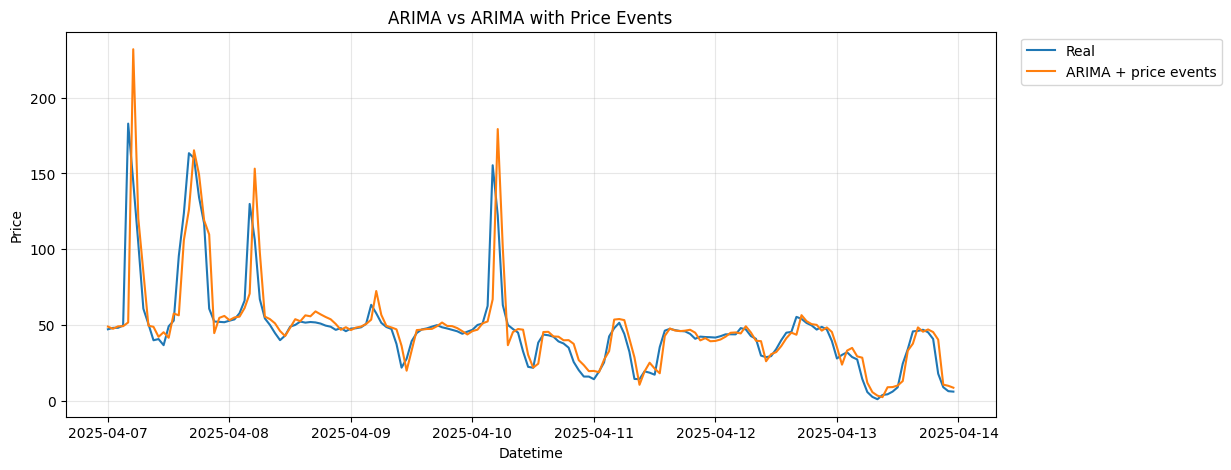

In [31]:
# ============================================================
# 12. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
# plt.plot(test.index, arima_pred_series, label="ARIMA")
plt.plot(test.index, event_pred_series, label="ARIMA + price events")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.title("ARIMA vs ARIMA with Price Events")
plt.xlabel("Datetime")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()

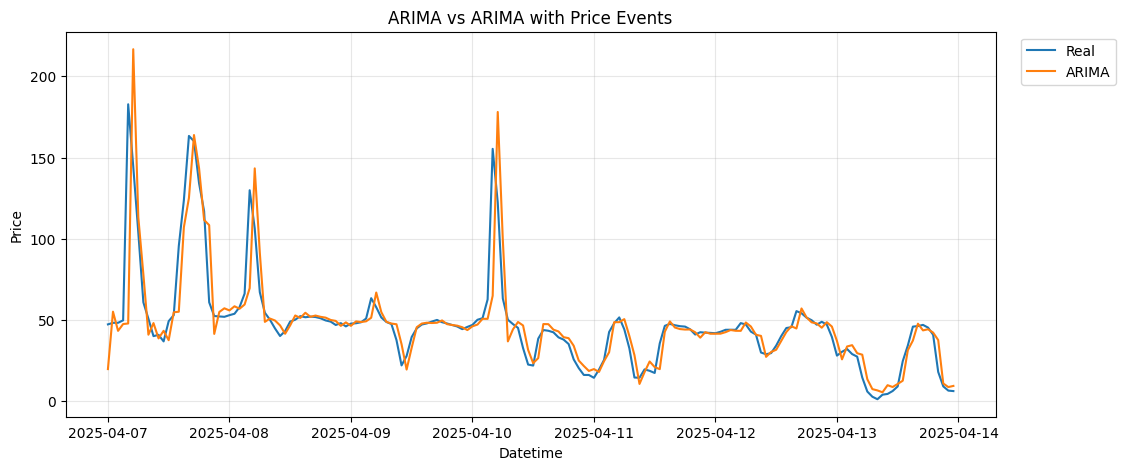

In [32]:
# ============================================================
# 12. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")
# plt.plot(test.index, event_pred_series, label="ARIMA + price events")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.title("ARIMA vs ARIMA with Price Events")
plt.xlabel("Datetime")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_squared_error, mean_squared_log_error

In [ ]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder

In [ ]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

builder = ModelDatasetBuilder(db_path)

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2025-10-01",
    add_time_features=False,
    lags=None,
    target_horizon=None,
    include_volumes=False,
    dropna=False
)

df.head()
df.tail()


,price_id,zone_id,delivery_day,hour,price_value
datetime,,,,,
2025-09-30 17:00:00,1007892,12,2025-09-30,19,69.96
2025-09-30 18:00:00,1007912,12,2025-09-30,20,59.94
2025-09-30 19:00:00,1007932,12,2025-09-30,21,52.99
2025-09-30 20:00:00,1007952,12,2025-09-30,22,47.38
2025-09-30 21:00:00,1007972,12,2025-09-30,23,43.98


In [ ]:
# ============================================================
# 4. CREATE TEMPORAL SERIES
# ============================================================

df_model = df[
    [
        "price_value"
    ]
].asfreq("h").dropna()

ts = df_model["price_value"]

print("Length:", ts.shape)
print("Duplicates:", ts.index.duplicated().sum())
print("Missing price:", ts.isna().sum())
print("Start:", ts.index.min())
print("End:", ts.index.max())

display(df_model.head())
display(df_model.tail())

Length: (50398,)
Duplicates: 0
Missing price: 0
Start: 2020-01-01 00:00:00
End: 2025-09-30 21:00:00


,price_value
datetime,
2020-01-01 00:00:00,31.77
2020-01-01 01:00:00,31.57
2020-01-01 02:00:00,31.28
2020-01-01 03:00:00,30.72
2020-01-01 04:00:00,30.27


,price_value
datetime,
2025-09-30 17:00:00,69.96
2025-09-30 18:00:00,59.94
2025-09-30 19:00:00,52.99
2025-09-30 20:00:00,47.38
2025-09-30 21:00:00,43.98


In [ ]:
# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

# ----------------------------
# Train: one full year
# ----------------------------
TRAIN_START = "2024-01-01 00:00:00"
TRAIN_END = "2024-12-31 23:00:00"

# ----------------------------
# Test: one random week in April 2025
# ----------------------------
np.random.seed(42)

possible_start_days = pd.date_range(
    start="2025-04-01",
    end="2025-04-24",
    freq="D"
)

random_test_start_day = np.random.choice(possible_start_days)

TEST_START = pd.Timestamp(random_test_start_day).strftime("%Y-%m-%d 00:00:00")
TEST_END = (
    pd.Timestamp(random_test_start_day) + pd.Timedelta(days=6, hours=23)
).strftime("%Y-%m-%d %H:%M:%S")

# ----------------------------
# Filter full available period
# ----------------------------
df_model_full = df_supervised.loc["2020-01-01":"2025-09-30 23:00:00"].copy()

train_df = df_model_full.loc[TRAIN_START:TRAIN_END].copy()
test_df = df_model_full.loc[TEST_START:TEST_END].copy()

train = train_df["target"]
test = test_df["target"]

exog_train_events = train_df[selected_price_features]
exog_test_events = test_df[selected_price_features]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

print("\nTrain:", train.shape)
print("Test:", test.shape)
print("Exog train events:", exog_train_events.shape)
print("Exog test events:", exog_test_events.shape)

print("\nRandom test week selected:")
print(TEST_START, "to", TEST_END)

display(exog_train_events.head())
display(exog_test_events.head())

Train period: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Test period: 2025-04-07 00:00:00 to 2025-04-13 23:00:00

Train: (8784,)
Test: (168,)
Exog train events: (8784, 16)
Exog test events: (168, 16)

Random test week selected:
2025-04-07 00:00:00 to 2025-04-13 23:00:00


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,48.98,2024,1,1,0,53.79,59.31,49.94,0,0,0,0,0,0,0,0
2024-01-01 01:00:00,27.45,2024,1,1,0,48.98,53.79,45.41,0,0,0,0,1,0,1,0
2024-01-01 02:00:00,24.48,2024,1,1,0,27.45,48.98,41.15,0,0,0,0,0,0,0,0
2024-01-01 03:00:00,24.01,2024,1,1,0,24.48,27.45,38.14,0,0,0,0,0,0,0,0
2024-01-01 04:00:00,21.23,2024,1,1,0,24.01,24.48,39.27,0,0,0,0,0,0,0,0


,price_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility
datetime,,,,,,,,,,,,,,,,
2025-04-07 00:00:00,48.14,2025,4,7,0,48.20,48.15,49.90,0,0,0,0,0,0,0,0
2025-04-07 01:00:00,47.30,2025,4,7,0,48.14,48.20,50.15,0,0,0,0,0,0,0,0
2025-04-07 02:00:00,48.25,2025,4,7,0,47.30,48.14,50.08,0,0,0,0,0,0,0,0
2025-04-07 03:00:00,48.27,2025,4,7,0,48.25,47.30,50.19,0,0,0,0,0,0,0,0
2025-04-07 04:00:00,49.79,2025,4,7,0,48.27,48.25,49.62,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# 9. ARIMA ROLLING ONE-STEP FORECAST
# ============================================================

arima_history = list(train)
arima_predictions = []

for t in range(len(test)):
    model = ARIMA(arima_history, order=(3, 0, 3))
    model_fit = model.fit()

    yhat = model_fit.forecast(steps=1)[0]
    arima_predictions.append(yhat)

    arima_history.append(test.iloc[t])

arima_pred_series = pd.Series(arima_predictions, index=test.index)

print("ARIMA predictions created:", arima_pred_series.shape)

ARIMA predictions created: (168,)


In [ ]:
# ============================================================
# 10. ARIMA WITH SELECTED PRICE EVENTS
# ============================================================

event_history_y = list(train)
event_history_exog = exog_train_events.copy()

event_predictions = []

for t in range(len(test)):
    model = SARIMAX(
        event_history_y,
        exog=event_history_exog,
        order=(3, 0, 3),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    yhat = model_fit.forecast(
        steps=1,
        exog=exog_test_events.iloc[[t]]
    ).iloc[0]

    event_predictions.append(yhat)

    event_history_y.append(test.iloc[t])
    event_history_exog = pd.concat(
        [event_history_exog, exog_test_events.iloc[[t]]]
    )

event_pred_series = pd.Series(event_predictions, index=test.index)

print("ARIMA with price events predictions created:", event_pred_series.shape)

ARIMA with price events predictions created: (168,)


Ejecution was working almost 17 minutes.

In [ ]:
# ============================================================
# 11. COMPARE RESULTS - RMSE AND RMSLE
# ============================================================

def evaluate_rmse_rmsle(y_true, y_pred):
    y_true = pd.Series(y_true).copy()
    y_pred = pd.Series(y_pred, index=y_true.index).copy()

    # RMSLE cannot handle negative values.
    # We clip only for RMSLE calculation.
    y_true_rmsle = np.maximum(y_true, 0)
    y_pred_rmsle = np.maximum(y_pred, 0)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true_rmsle, y_pred_rmsle))
    }

results = pd.DataFrame({
    "ARIMA_full_price_series": evaluate_rmse_rmsle(test, arima_pred_series),
    "ARIMA_price_events": evaluate_rmse_rmsle(test, event_pred_series)
}).T

baseline_rmse = results.loc["ARIMA_full_price_series", "RMSE"]
baseline_rmsle = results.loc["ARIMA_full_price_series", "RMSLE"]

results["RMSE_improvement_vs_ARIMA_%"] = (
    (baseline_rmse - results["RMSE"]) / baseline_rmse * 100
)

results["RMSLE_improvement_vs_ARIMA_%"] = (
    (baseline_rmsle - results["RMSLE"]) / baseline_rmsle * 100
)

results

,RMSE,RMSLE,RMSE_improvement_vs_ARIMA_%,RMSLE_improvement_vs_ARIMA_%
ARIMA_full_price_series,17.803358,0.279825,0.000000,0.000000
ARIMA_price_events,18.194394,0.259251,-2.196421,7.352671


In [ ]:
# ============================================================
# 13. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")
plt.plot(test.index, sarimax_pred_series, label="SARIMAX + volumes")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.title("ARIMA vs SARIMAX with Volumes")
plt.show()

NameError: name 'plt' is not defined

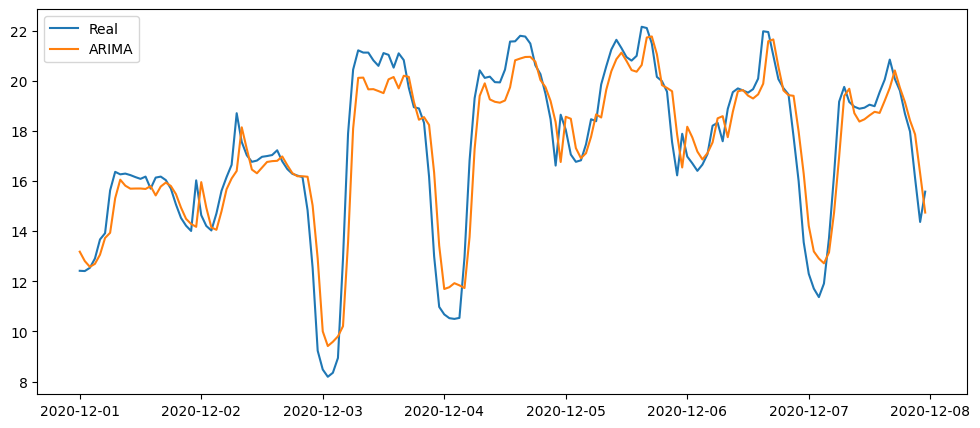

In [ ]:
# ============================================================
# 15. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")

plt.legend()
plt.show()

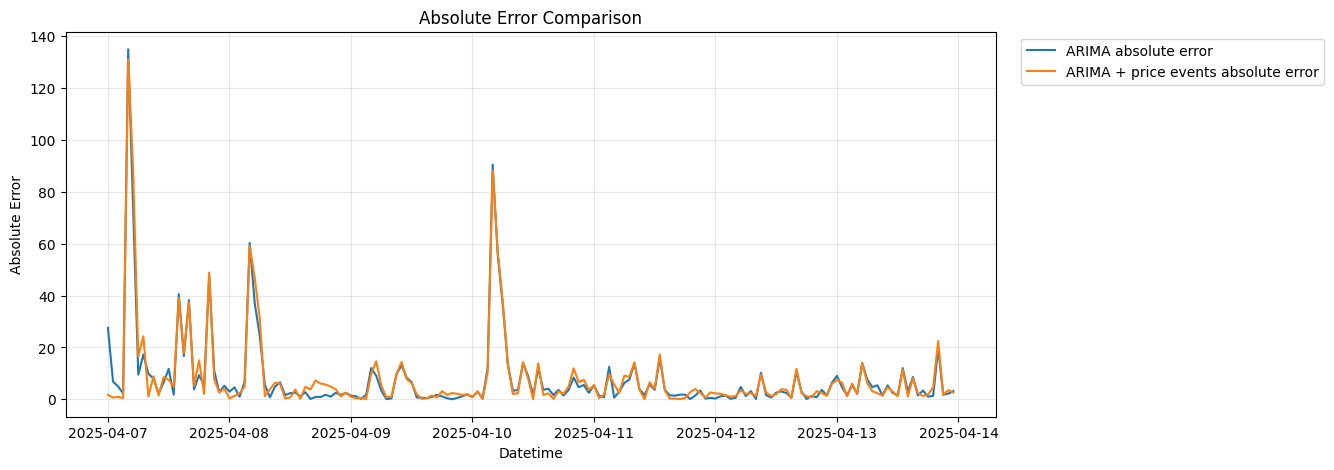

In [33]:
# ============================================================
# 13. ABSOLUTE ERROR COMPARISON
# ============================================================

error_comparison = pd.DataFrame(index=test.index)

error_comparison["ARIMA_abs_error"] = np.abs(test - arima_pred_series)
error_comparison["ARIMA_price_events_abs_error"] = np.abs(test - event_pred_series)

plt.figure(figsize=(12, 5))

plt.plot(
    error_comparison.index,
    error_comparison["ARIMA_abs_error"],
    label="ARIMA absolute error"
)

plt.plot(
    error_comparison.index,
    error_comparison["ARIMA_price_events_abs_error"],
    label="ARIMA + price events absolute error"
)

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.title("Absolute Error Comparison")
plt.xlabel("Datetime")
plt.ylabel("Absolute Error")
plt.grid(True, alpha=0.3)
plt.show()